<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [1]:
%pylab inline
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline


from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# from google.colab import drive # Если вы работаете в коллабе
# drive.mount('/content/drive')

# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [3]:
class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        if gd_type not in ['full', 'stochastic']:
            raise Exception("gd_type must be 'full' or 'stochastic'")
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        X = np.hstack((np.ones((X.shape[0], 1)), X))

        if self.w0:
            self.w = self.w0.copy()
        else:
            self.w = np.random.random(size=X.shape[1])
        self.loss_history.append(self.calc_loss(X, y))

        for i in range(self.max_iter):
            if self.gd_type == 'stochastic':
                idx = np.random.randint(X.shape[0])
                gradient = self.calc_gradient(X=X[idx, :].reshape(1, -1).copy(), y=y[idx].reshape(-1).copy())
            else:
                gradient = self.calc_gradient(X=X.copy(), y=y.copy())
            w_new = self.w - self.eta  * gradient

            if np.linalg.norm(w_new - self.w) < self.tolerance:
                self.loss_history.append(self.calc_loss(X, y))
                break
            self.w = w_new
            self.loss_history.append(self.calc_loss(X, y))

        return self

    def sigmoid(self, X):
        return 1 / (1 + np.exp(-X @ self.w))

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        X = np.hstack((np.ones((X.shape[0], 1)), X))
        p = self.sigmoid(X)
        return p

    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        X = np.hstack((np.ones((X.shape[0], 1)), X))
        p = self.sigmoid(X)
        return np.where(p > 0.5, 1, 0)


    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        p = self.sigmoid(X)
        return X.T @ (p - y) / len(y)


    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        p = self.sigmoid(X)
        return - np.mean(y @ np.log(p) + (1 - y) @ (np.log(1 - p)))


Теперь проверим работу вашего класса на синтетических данных.

In [4]:


X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [5]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


LogReg(gd_type='full')

In [6]:
sgd_preds = lr_sgd.predict(X_test)
sgd_probas = lr_sgd.predict_proba(X_test)

full_preds = lr_full.predict(X_test)
full_probas = lr_full.predict_proba(X_test)

In [7]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

preds = lr.predict(X_test)
probas = lr.predict_proba(X_test)[:, 1]

In [8]:
sgd_accuracy = accuracy_score(y_test, sgd_preds)
sgd_roc_auc = roc_auc_score(y_test, sgd_probas)

full_accuracy = accuracy_score(y_test, full_preds)
full_roc_auc = roc_auc_score(y_test, full_probas)

accuracy = accuracy_score(y_test, preds)
roc_auc_ = roc_auc_score(y_test, probas)

print(f"SGD model: accuracy={sgd_accuracy}, ROC_AUC={sgd_roc_auc}")
print(f"Full model: accuracy={full_accuracy}, ROC_AUC={full_roc_auc}")
print(f"SKLearn model: accuracy={accuracy}, ROC_AUC={roc_auc_}")

SGD model: accuracy=0.6772333333333334, ROC_AUC=0.7478725157794994
Full model: accuracy=0.8484, ROC_AUC=0.9262056399478164
SKLearn model: accuracy=0.8681, ROC_AUC=0.9398924765443586


In [9]:
sgd_roc_auc

np.float64(0.7478725157794994)

In [10]:
sgd_fpr, sgd_tpr, sgd_thresholds = roc_curve(y_test, sgd_probas)
sgd_roc_auc = auc(sgd_fpr, sgd_tpr)

full_fpr, full_tpr, full_thresholds = roc_curve(y_test, full_probas)
full_roc_auc = auc(full_fpr, full_tpr)

fpr, tpr, thresholds = roc_curve(y_test, probas)
roc_auc = auc(fpr, tpr)

ROC-AUC Curve


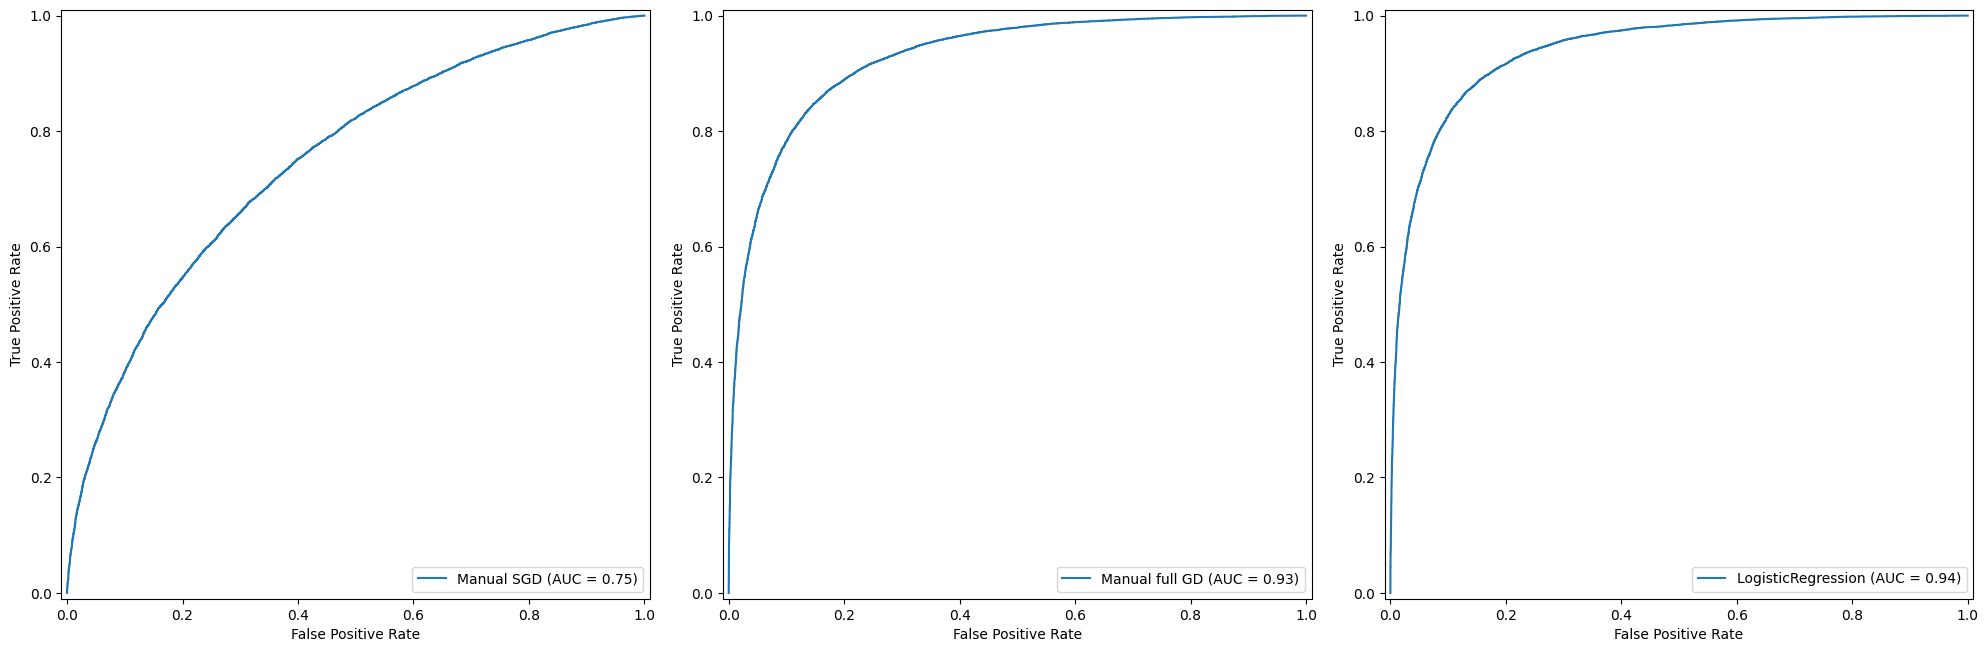

In [11]:
print('ROC-AUC Curve')

fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(20, 10))


display_sgd = RocCurveDisplay(fpr=sgd_fpr, tpr=sgd_tpr, roc_auc=sgd_roc_auc, estimator_name='Manual SGD')
display_sgd.plot(ax=axes[0])

display_full = RocCurveDisplay(fpr=full_fpr, tpr=full_tpr, roc_auc=full_roc_auc, estimator_name='Manual full GD')
display_full.plot(ax=axes[1])

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='LogisticRegression')
display.plot(ax=axes[2])

plt.tight_layout()
plt.show()

PR-AUC Curve


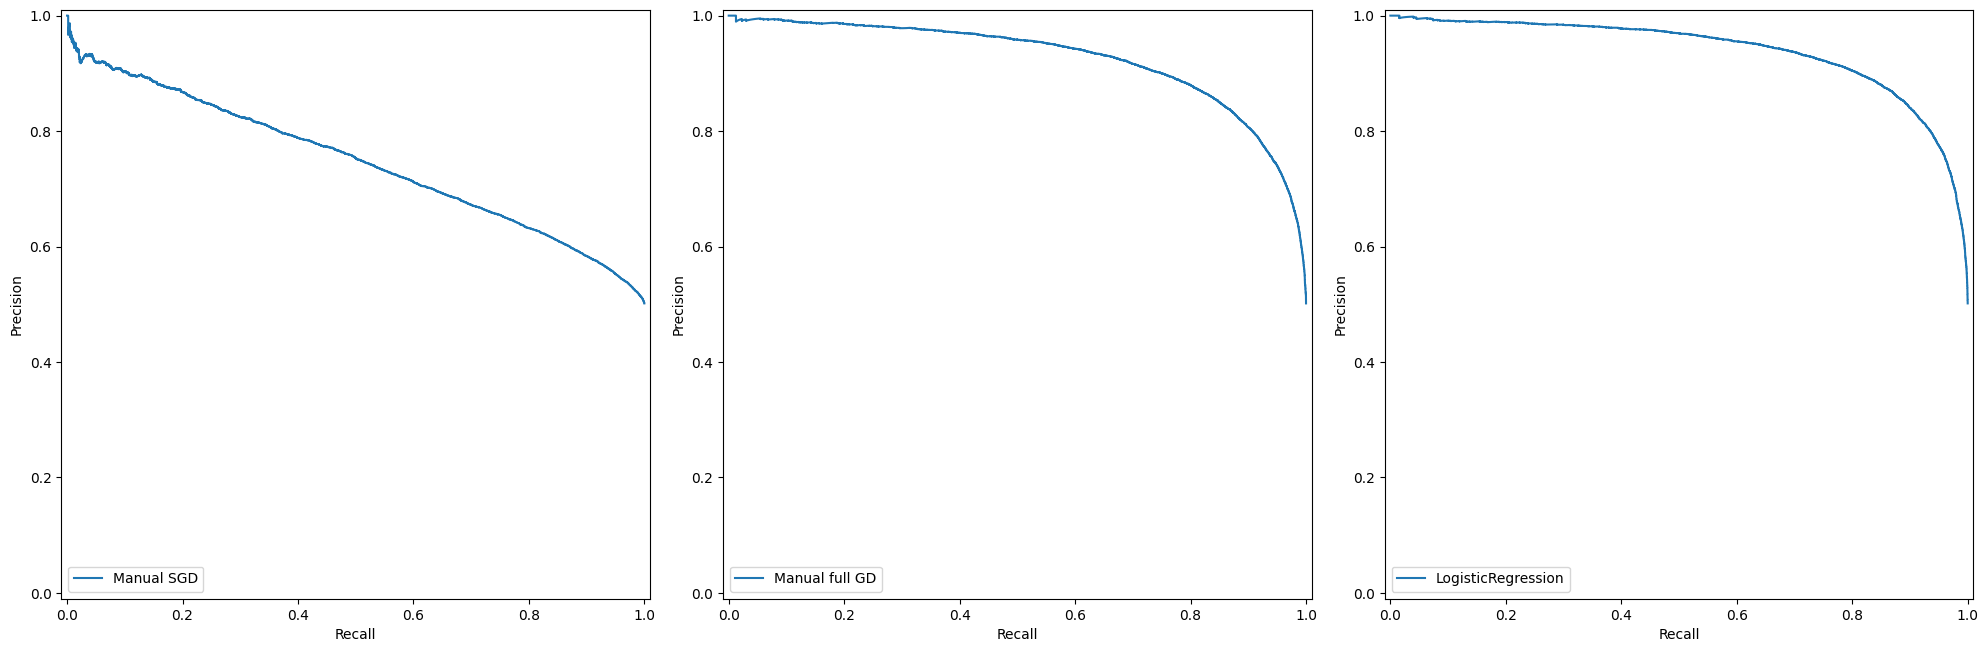

In [12]:
print('PR-AUC Curve')

fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(20, 10))

precision_sgd, recall_sgd, _ = precision_recall_curve(y_test, sgd_probas)
pr_display_sgd = PrecisionRecallDisplay(precision=precision_sgd, recall=recall_sgd, estimator_name='Manual SGD').plot(ax=axes[0])

precision_full, recall_full, _ = precision_recall_curve(y_test, full_probas)
pr_display_full = PrecisionRecallDisplay(precision=precision_full, recall=recall_full, estimator_name='Manual full GD').plot(ax=axes[1])

precision, recall, _ = precision_recall_curve(y_test, probas)
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='LogisticRegression').plot(ax=axes[2])

plt.tight_layout()
plt.show()

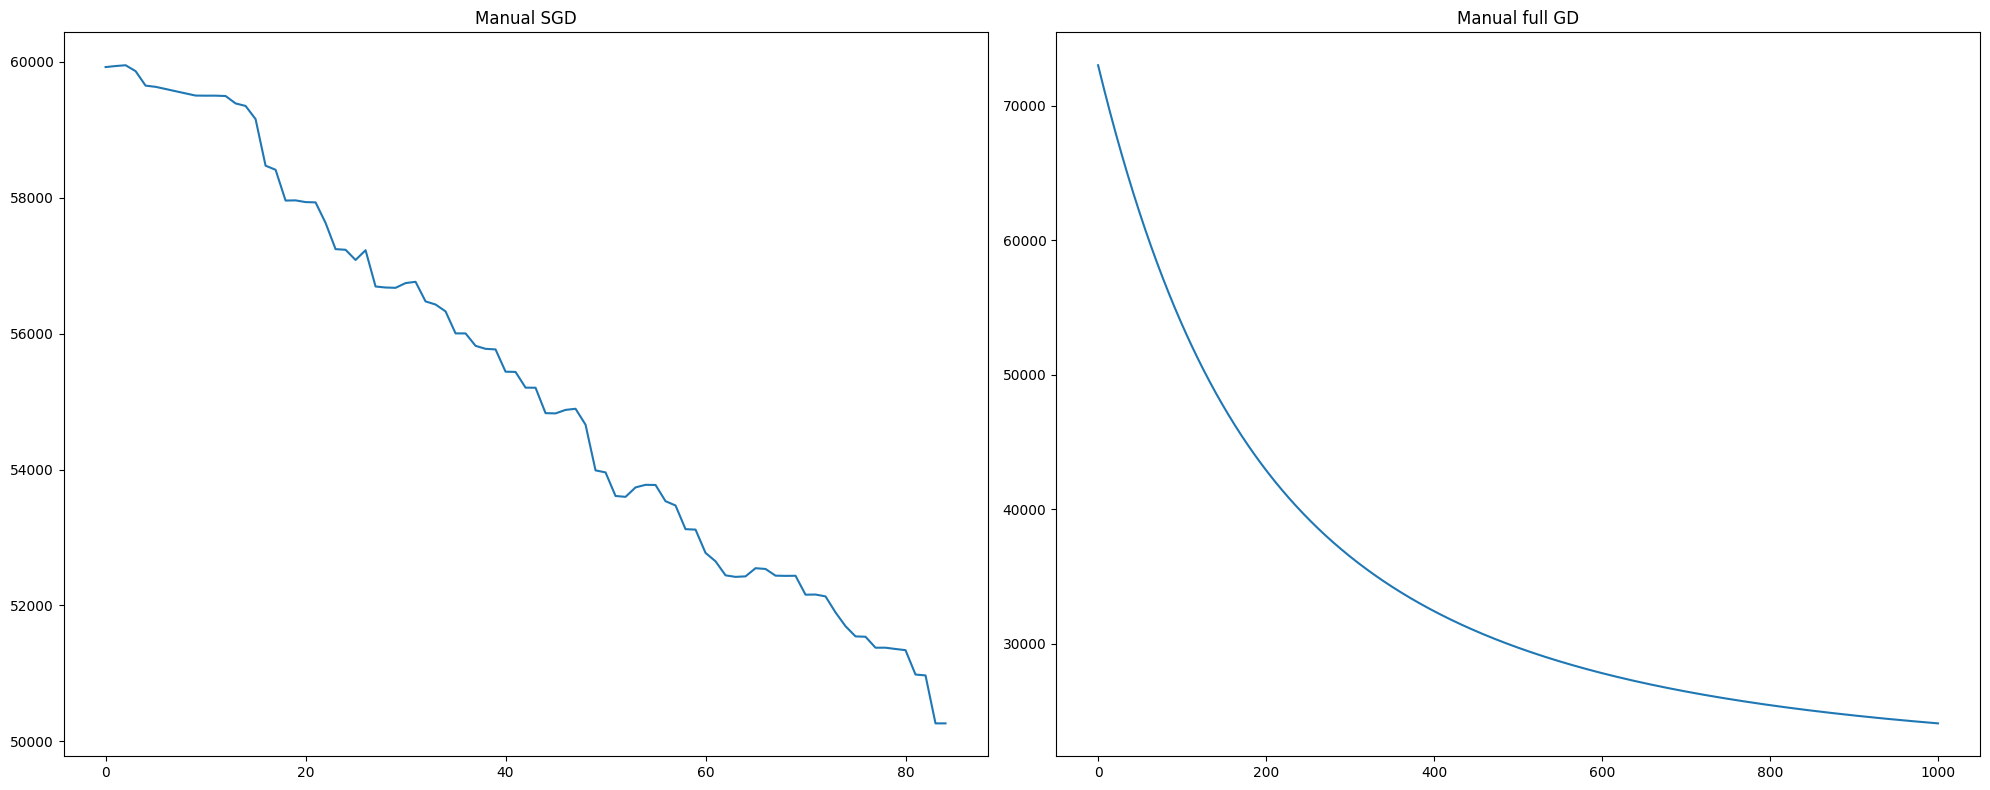

In [13]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(20, 8))

axes[0].plot(lr_sgd.loss_history)
axes[0].set_title('Manual SGD')

axes[1].plot(lr_full.loss_history)
axes[1].set_title('Manual full GD')

plt.tight_layout()
plt.show()

**Ответы на вопросы**  
- Какая показывает лучший результат? Почему?  
Наилучший результат показала библиотечная версия модели, но градиентный спуск с параметром `d_type='full'` очень близок к нему. Думаю, что библиотечная модель показала себя лучше всего, т.к. в ней реализованы и другие параметры, которых нет в моей реализации. Например, регуляризации (по умолчанию идет `l2`) или `solver` - алгоритм оптимизации. Реализованная версия с `d_type='full'` показала лучше результат, т.к. при обучении использовался весь тренировочный датасет и процесс обучения шел более ладно. Как видно на графиках выше у `SGD` сработал критерий останова по `tolerance`, при этом ошибка в этот момент была намного выше.  
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели?  
Как я указал выше, в библиотечной модели по умолчанию используется `l2`-регуляризация. Это дает ей преимущество над реализованными моделями.

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

In [14]:
sgd_preds_std = StandardScaler().fit_transform(sgd_preds.reshape(-1, 1))
full_preds_std = StandardScaler().fit_transform(full_preds.reshape(-1, 1))
preds_std = StandardScaler().fit_transform(preds.reshape(-1, 1))

In [15]:
sgd_preds_std_pca = PCA().fit_transform(sgd_preds_std)
full_preds_std_pca = PCA().fit_transform(full_preds_std)
preds_std_pca = PCA().fit_transform(preds_std)

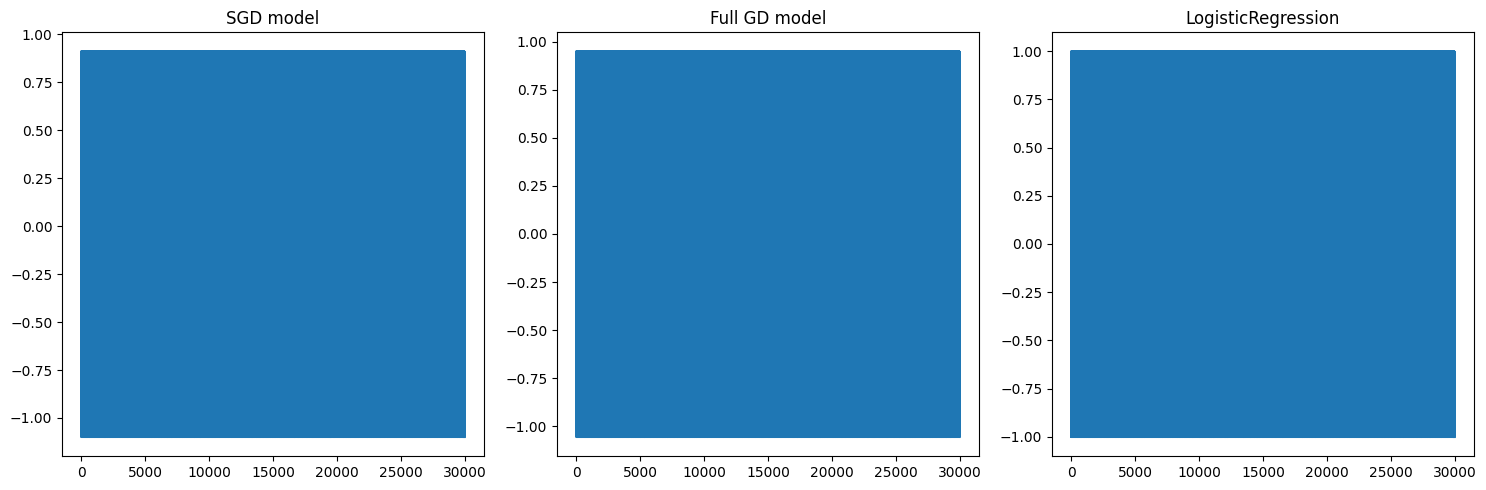

In [16]:
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(15, 5))

sns.lineplot(data=sgd_preds_std_pca, ax=axes[0], legend=False)
axes[0].set_title('SGD model')

sns.lineplot(data=full_preds_std_pca, ax=axes[1], legend=False)
axes[1].set_title('Full GD model')

sns.lineplot(data=preds_std_pca, ax=axes[2], legend=False)
axes[2].set_title('LogisticRegression')

plt.tight_layout()
plt.show()

**Ответ**  
После сжатия данных методом PCA получились 3 одинаковых графика.

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [17]:
PATH = './data/train.csv'
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [18]:
data.isna().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Да, в `keyword` и `location` есть пропуски

In [19]:
data = data.fillna({'keyword': '', 'location': ''})
data.isna().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [20]:
for col in ['id','keyword', 'location', 'target']:
    print(f"{col}: {data[col].nunique()}")

id: 7613
keyword: 222
location: 3342
target: 2


В `target` присутствуют 2 класса, значит предстоит бинарная классификация.  
В `target` - 222 уникальных значения, включая пустые строки, которыми я заполнил пропуски на предыдущем этапе, а в `location` - 3342 уникальных значения

- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [21]:
data['target'].value_counts(normalize=True)

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

Значений обоих классов в выборке примерно поровну, но разница всё-таки в 15%, так что буду использовать $R^2$, чтобы избезать искажения метрики `Accuracy`.

- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [22]:
data.sample(5)

,id,keyword,location,text,target
4582,6515,injuries,Bay Area,Forsure back in the gym tomorrow. Body isn't e...,0
4105,5834,hail,United States,UNR issues Severe Thunderstorm Warning [wind: ...,1
6665,9553,threat,"Arlington, VA",Get access to the most extensive sources of th...,0
6947,9965,tsunami,"Washington, DC",I'm at Baan Thai / Tsunami Sushi in Washington...,0
1938,2786,curfew,"Elkhart, IN",Had to cancel my cats doctor appointment becau...,0


In [23]:
data['full_text'] = data['keyword'] + '; ' + data['location'] + '; ' + data['text']
data.sample(5)

,id,keyword,location,text,target,full_text
1922,2765,curfew,Im Around ... Jersey,Curfew really helps If you think about it ... #BC,0,curfew; Im Around ... Jersey; Curfew really he...
6185,8830,sirens,"Decatur, GA",'If you looking for my niggas you can follow t...,0,"sirens; Decatur, GA; 'If you looking for my ni..."
557,806,battle,San Francisco,What really happened in the Taken King Story T...,0,battle; San Francisco; What really happened in...
2634,3777,destruction,,Crackdown 3 Destruction Restricted to Multipla...,0,destruction; ; Crackdown 3 Destruction Restric...
4567,6493,injuries,"Milton Keynes, England",If you're slating @gpaulista5 for @JackWilsher...,0,"injuries; Milton Keynes, England; If you're sl..."


- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [24]:
X = data['full_text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [25]:
count_vec = CountVectorizer()
X_train_cv = count_vec.fit_transform(X_train)
X_train_cv.shape

(5329, 18455)

Получилась матрица размером (5329, 18455)

- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [26]:
lr_text = LogisticRegression()
lr_text.fit(X_train_cv, y_train)

LogisticRegression()

In [27]:
X_test_cv = count_vec.transform(X_test)

lr_text_preds = lr_text.predict(X_test_cv)

In [28]:
r2_score(y_test, lr_text_preds)

0.17838371081097226

Качество модели получилось 0.17838371081097226 по $R^2$

- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [29]:
svc_text = SVC()
svc_text.fit(X_train_cv, y_train)

svc_text_preds = svc_text.predict(X_test_cv)
r2_score(y_test, svc_text_preds)

0.19991077515653632

Качествро немного выросло - на 0.0215

### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [30]:
count_vec_v2 = CountVectorizer(max_features=X_train.shape[0] // 4)
X_train_cv_v2 = count_vec_v2.fit_transform(X_train)
X_test_cv_v2 = count_vec_v2.transform(X_test)
X_train_cv_v2.shape

(5329, 1332)

In [31]:
lr_text_v2 = LogisticRegression()
lr_text_v2.fit(X_train_cv_v2, y_train)

lr_text_preds_v2 = lr_text_v2.predict(X_test_cv_v2)
r2_score(y_test, lr_text_preds_v2)

0.12456604994706222

In [32]:
r2_score(y_test, lr_text_preds_v2) - r2_score(y_test, lr_text_preds)

-0.053817660863910044

In [33]:
svc_text_v2 = SVC()
svc_text_v2.fit(X_train_cv_v2, y_train)

svc_text_preds_v2 = svc_text_v2.predict(X_test_cv_v2)
r2_score(y_test, svc_text_preds_v2)

0.1550627244366113

In [34]:
r2_score(y_test, svc_text_preds_v2) - r2_score(y_test, svc_text_preds)

-0.04484805071992504

Результат вписывается в установленное ограничение по максимальному изменению качества модели. После существенного сокращения количества признаков, качество обеих моделей упало.  
У `CountVectorizer` определил всего 1 параметр - `max_features`. Он указываем максимальное количество фичей, которое должно быть в трансформированнной матрице. При указанном значении в этом параметре `CountVectorizer` оставляет в результирующей матрице только ТОП-N признаков по частоте их встречаемости в текстах

### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [35]:
X = data[['keyword', 'location', 'text']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [36]:
col_transformers = ColumnTransformer(transformers=[
    ('keyword_vec', CountVectorizer(), 'keyword'),
    ('location_vec', CountVectorizer(), 'location'),
    ('text_vec', CountVectorizer(), 'text')
], remainder='passthrough')
X_train_cv_transform = col_transformers.fit_transform(X_train)
X_test_cv_transform = col_transformers.transform(X_test)

In [37]:
lr_text_v2 = LogisticRegression()
lr_text_v2.fit(X_train_cv_transform, y_train)

lr_text_preds_v2 = lr_text_v2.predict(X_test_cv_transform)
r2_score(y_test, lr_text_preds_v2)

0.20349861921413037

In [38]:
svc_text_v2 = SVC()
svc_text_v2.fit(X_train_cv_transform, y_train)

svc_text_preds_v2 = svc_text_v2.predict(X_test_cv_transform)
r2_score(y_test, svc_text_preds_v2)

0.21246822935811538

После применения `CountVectorizer` к каждому из столбцов в отдельности, качество классификации у `LogisticRegression` выросло на 0.0251.  
У `SVC` также выросло качество на 0.0126

### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [45]:
lr_params_grid = {
    'C': np.arange(0.1, 2.2, 0.5),
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'max_iter': [100, 300, 500]
}

In [46]:
%%time
lr_model = LogisticRegression()
gs_lr = GridSearchCV(lr_model, param_grid=lr_params_grid, scoring='r2', cv=5, n_jobs=3, verbose=2)
gs_lr.fit(X_train_cv_transform, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END ..................C=0.1, max_iter=100, solver=lbfgs; total time=   0.9s
[CV] END ..................C=0.1, max_iter=100, solver=lbfgs; total time=   1.3s
[CV] END ..................C=0.1, max_iter=100, solver=lbfgs; total time=   1.9s
[CV] END ..............C=0.1, max_iter=100, solver=liblinear; total time=   0.1s
[CV] END ..................C=0.1, max_iter=100, solver=lbfgs; total time=   0.7s
[CV] END ..................C=0.1, max_iter=100, solver=lbfgs; total time=   1.3s
[CV] END ..............C=0.1, max_iter=100, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.1, max_iter=100, solver=liblinear; total time=   0.2s
[CV] END ..............C=0.1, max_iter=100, solver=liblinear; total time=   0.1s
[CV] END ..............C=0.1, max_iter=100, solver=newton-cg; total time=   0.1s
[CV] END ..............C=0.1, max_iter=100, solver=liblinear; total time=   0.2s
[CV] END ..............C=0.1, max_iter=100, sol

/home/rattler/HSE/Homeworks/hse_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/rattler/HSE/Homeworks/hse_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ....................C=0.1, max_iter=100, solver=sag; total time=   0.1s
[CV] END ....................C=0.1, max_iter=100, solver=sag; total time=   0.2s


/home/rattler/HSE/Homeworks/hse_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ....................C=0.1, max_iter=100, solver=sag; total time=   0.1s
[CV] END ....................C=0.1, max_iter=100, solver=sag; total time=   0.1s


...

/home/rattler/HSE/Homeworks/hse_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ...................C=2.1, max_iter=500, solver=saga; total time=   1.1s


/home/rattler/HSE/Homeworks/hse_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ...................C=2.1, max_iter=500, solver=saga; total time=   1.0s
[CV] END ........C=2.1, max_iter=500, solver=newton-cholesky; total time= 5.2min
[CV] END ........C=2.1, max_iter=500, solver=newton-cholesky; total time= 5.3min
CPU times: user 24.4 s, sys: 6.55 s, total: 31 s
Wall time: 2h 21min 37s


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=3,
             param_grid={'C': array([0.1, 0.6, 1.1, 1.6, 2.1]),
                         'max_iter': [100, 300, 500],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='r2', verbose=2)

In [47]:
gs_lr.best_score_

np.float64(0.15061995877682008)

In [48]:
gs_lr.best_params_

{'C': np.float64(0.1), 'max_iter': 100, 'solver': 'saga'}

In [49]:
lr_model_best = gs_lr.best_estimator_
lr_model_gs_preds = lr_model_best.predict(X_test_cv_transform)
r2_score(y_test, lr_model_gs_preds)

0.2393770597900704

Описание подбираемых параметров `LogisticRegression`:  
- `C` - значение, обратно пропорчиональное силе регуляризации (должен быть положительным). Контролирует уровень регуляризации - чем меньше значение, тем сильнее регуляризация
- `solver` - алгоритм оптимизации
- `max_iter` - ограничение по максимальному количеству итераций обучения
**Выводы.**  
Подбор гиперпараметров модели помог улучшить метрику качества на 0.0359

- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [39]:
svc_params_grid = {
    'C': np.arange(0.1, 2.2, 0.5),
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

In [40]:
%%time
svc_model = SVC()
gs_svc = GridSearchCV(svc_model, param_grid=svc_params_grid, scoring='r2', cv=5, n_jobs=3, verbose=2)
gs_svc.fit(X_train_cv_transform, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ...............................C=0.1, kernel=linear; total time=   2.0s
[CV] END ...............................C=0.1, kernel=linear; total time=   2.6s
[CV] END ...............................C=0.1, kernel=linear; total time=   2.6s
[CV] END ...............................C=0.1, kernel=linear; total time=   1.8s
[CV] END ...............................C=0.1, kernel=linear; total time=   2.4s
[CV] END .................................C=0.1, kernel=poly; total time=   3.0s
[CV] END .................................C=0.1, kernel=poly; total time=   2.9s
[CV] END .................................C=0.1, kernel=poly; total time=   2.3s
[CV] END .................................C=0.1, kernel=poly; total time=   3.7s
[CV] END .................................C=0.1, kernel=poly; total time=   3.4s
[CV] END ..................................C=0.1, kernel=rbf; total time=   2.2s
[CV] END ..................................C=0.

GridSearchCV(cv=5, estimator=SVC(), n_jobs=3,
             param_grid={'C': array([0.1, 0.6, 1.1, 1.6, 2.1]),
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='r2', verbose=2)

In [41]:
gs_svc.best_score_

np.float64(0.1582630440638775)

In [42]:
gs_svc.best_params_

{'C': np.float64(2.1), 'kernel': 'rbf'}

In [43]:
svc_model_best = gs_svc.best_estimator_
svc_model_gs_preds = svc_model_best.predict(X_test_cv_transform)
r2_score(y_test, svc_model_gs_preds)

0.23758313776127338

Описание подбираемых параметров `SVC`:  
- `C` - параметр регуляризации. Строго положительный и обратно пропорционален силе регуляризации
- `kernel` - тип ядра, используемый в алгоритме
**Выводы.**  
Подбор гиперпараметров модели помог улучшить метрику качества на 0.0251

**Вывод**  
Подбор гиперпараметров моделей помог модели `LogisticRegression` вырваться вперед и показать результат лучше, чем у `SVC`.

### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

In [40]:
pipeline_lr = Pipeline([
    ('col_transform', ColumnTransformer(transformers=[
        ('keyword_vec', CountVectorizer(), 'keyword'),
        ('location_vec', CountVectorizer(), 'location'),
        ('text_vec', CountVectorizer(), 'text')
    ], remainder='passthrough')),
    ('model', LogisticRegression(C=0.1, max_iter=300, solver='saga'))
])
pipeline_lr.fit(X_train, y_train)
pipeline_lr_preds = pipeline_lr.predict(X_test)
r2_score(y_test, pipeline_lr_preds)

0.24117098181886742

In [41]:
pipeline_svc = Pipeline([
    ('col_transform', ColumnTransformer(transformers=[
        ('keyword_vec', CountVectorizer(), 'keyword'),
        ('location_vec', CountVectorizer(), 'location'),
        ('text_vec', CountVectorizer(), 'text')
    ], remainder='passthrough')),
    ('model', SVC(C=2.1, kernel='rbf'))
])
pipeline_svc.fit(X_train, y_train)
pipeline_svc_preds = pipeline_svc.predict(X_test)
r2_score(y_test, pipeline_svc_preds)

0.23758313776127338

**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤

Исли поработать с предобработкой текстов, уверен, получится еще поднять качество классификации. Но, конечно, до NN линейным моделям очень далеко. Хотя удивляет, что они показывают даже такое качество при работе с текстовыми данными, хоть и приведенными к числам.